<a href="https://colab.research.google.com/github/Niyathi189/finalyr-project/blob/main/phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

In [ ]:
import os

print(os.listdir("images"))

['OralCancer']


In [ ]:
import os
print(os.listdir("images/OralCancer")[:10])

['cancer', 'non-cancer']


In [ ]:
def predict_cancer(image_path):
    import cv2
    import numpy as np

    img = cv2.imread(image_path)
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)

    if prediction[0][0] > 0.5:
        return "Cancer Detected"
    else:
        return "No Cancer"

In [ ]:
import os
print(os.listdir())

['.config', 'images', 'questionairre.xlsx', 'archive (3).zip', 'sample_data']


In [ ]:
df_cancer = df[df['Oral Cancer (Diagnosis)'] == 'Yes']
print(df_cancer.shape)

(42349, 19)


In [ ]:
df_cancer['Stage_Group'] = df_cancer['Cancer Stage'].apply(
    lambda x: 0 if x == 1 else 1
)

print(df_cancer['Stage_Group'].value_counts())

Stage_Group
1    29636
0    12713
Name: count, dtype: int64


/tmp/ipykernel_177/3041952070.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cancer['Stage_Group'] = df_cancer['Cancer Stage'].apply(


In [ ]:
df_cancer = df[df['Oral Cancer (Diagnosis)'] == 'Yes'].copy()

In [ ]:
df_cancer['Stage_Group'] = df_cancer['Cancer Stage'].apply(
    lambda x: 0 if x == 1 else 1
)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

In [ ]:
risk_features = [
    'Tobacco Use',
    'Alcohol Consumption',
    'HPV Infection',
    'Betel Quid Use',
    'Poor Oral Hygiene',
    'Family History of Cancer',
    'Oral Lesions',
    'Unexplained Bleeding',
    'Difficulty Swallowing',
    'White or Red Patches in Mouth'
]

df['Risk_Score'] = 0

for col in risk_features:
    df['Risk_Score'] += df[col].apply(lambda x: 1 if x == 'Yes' else 0)

In [ ]:
X = df.drop(columns=[
    'Risk_Score',
    'Risk_Level',
    'Cancer Stage',
    'Oral Cancer (Diagnosis)',
    'Treatment Type',
    'ID',
    'Unexplained Bleeding',  # remove some strong predictors
    'Oral Lesions',
    'White or Red Patches in Mouth'
])

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Risk_Score", axis=1)
y = df["Risk_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y   # important for 3 classes
)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert all categorical columns to numbers
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop("Risk_Score", axis=1)
y = df["Risk_Score"]

In [86]:
def risk_level(score):
    if score <= 2:
        return 1   # Low Risk
    elif score <= 5:
        return 2   # Medium Risk
    else:
        return 3   # High Risk

df['Risk_Level'] = df['Risk_Score'].apply(risk_level)

print(df['Risk_Level'].value_counts())

Risk_Level
2    58858
3    15674
1    10390
Name: count, dtype: int64
Risk_Level
2    58858
3    15674
1    10390
Name: count, dtype: int64


In [88]:
y = df["Risk_Class"]

In [89]:
X = df.drop(["Risk_Score", "Risk_Class"], axis=1)
y = df["Risk_Class"]   # 👈 VERY IMPORTANT

In [90]:
X = pd.get_dummies(X, drop_first=True)

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [92]:
from sklearn.ensemble import RandomForestClassifier

risk_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

risk_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [93]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = risk_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8336931349844958
[[ 6391  1916     0]
 [ 1366 13991   279]
 [    0   676   858]]


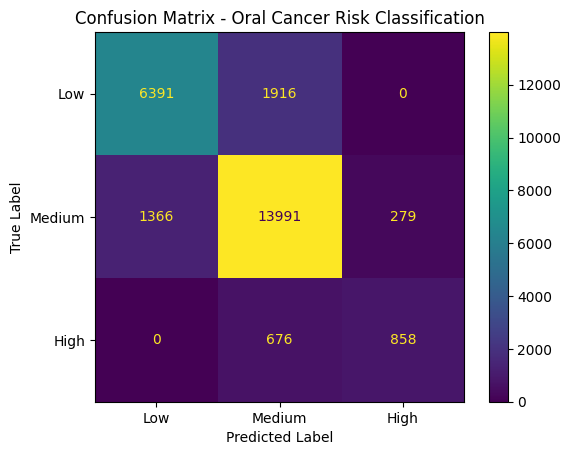

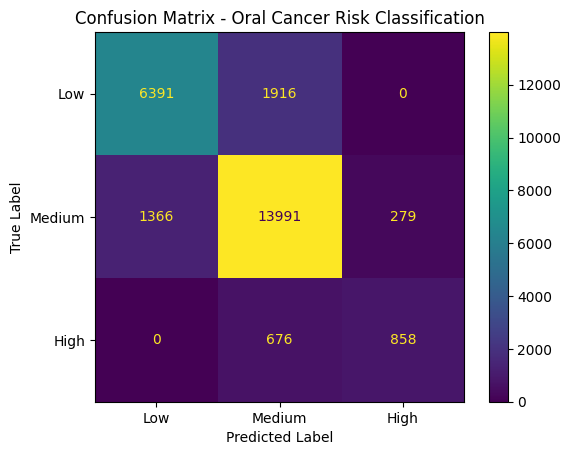

In [96]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict
y_pred = risk_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display as graph
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"])
disp.plot()

plt.title("Confusion Matrix - Oral Cancer Risk Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [97]:
import os
print(os.getcwd())

/content


In [98]:
import os
print(os.listdir("/content"))

['.config', 'images', 'questionairre.xlsx', 'archive (3).zip', 'sample_data']


In [99]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [101]:
import os
print(os.listdir("/content"))

['.config', 'images', 'questionairre.xlsx', 'archive (3).zip', 'drive', 'sample_data']
